# Prediccion de Ventas por Sucursal - Metodologia CRISP-DM
## Analisis de Series de Tiempo para HGC Bolivia
Notebook profesional para entrenamiento, evaluacion y seleccion del mejor modelo predictivo.


## 1. Business Understanding
**Problema:** Prediccion del comportamiento de ventas para planificacion financiera y evaluacion de apertura de nuevas sucursales.
**Objetivo:** Construir un modelo de series temporales que proyecte ventas a 6 meses con intervalo de confianza del 95%.
**Preguntas clave:**
- Cual es la tendencia de crecimiento organico por sucursal?
- Existe estacionalidad semanal o mensual significativa?
- Que modelo (ARIMA, SARIMA, XGBoost, Random Forest, Linear Regression) ofrece mejor precision?


## 2. Data Understanding
### 2.1 Carga de datos desde Snowflake


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import snowflake.connector
import os, warnings
from dotenv import load_dotenv
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import pickle
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
load_dotenv('../../.env')
print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


In [2]:
conn = snowflake.connector.connect(
    user=os.environ.get('SNOWFLAKE_USER'),
    password=os.environ.get('SNOWFLAKE_PASSWORD'),
    account=os.environ.get('SNOWFLAKE_ACCOUNT'),
    warehouse=os.environ.get('SNOWFLAKE_WAREHOUSE'),
    database=os.environ.get('SNOWFLAKE_DATABASE'),
    role=os.environ.get('SNOWFLAKE_ROLE'),
    schema='GOLD'
)
df = pd.read_sql('SELECT * FROM mart_ventas_historicas', conn)
conn.close()
df['FECHA'] = pd.to_datetime(df['FECHA'])
df = df.sort_values(['ID_SUCURSAL_SK','FECHA'])
print(f'Registros: {len(df)}, Sucursales: {df["ID_SUCURSAL_SK"].nunique()}')
df.head(10)

Registros: 30706, Sucursales: 12


,FECHA,ID_SUCURSAL_SK,NOMBRE_SUCURSAL,VENTAS_REALES,COMISIONES,MERMAS,COSTOS
10034,2022-02-15,291efd9e17956f4c876ffb0bf5c9208d,HGC Av. Monseñor Rivero,7119.0,441.54,173.7036,2491.65
10043,2022-02-16,291efd9e17956f4c876ffb0bf5c9208d,HGC Av. Monseñor Rivero,7102.0,382.14,173.2888,2485.70
10052,2022-02-17,291efd9e17956f4c876ffb0bf5c9208d,HGC Av. Monseñor Rivero,6118.0,375.10,149.2792,2141.30
10061,2022-02-18,291efd9e17956f4c876ffb0bf5c9208d,HGC Av. Monseñor Rivero,8926.0,717.86,217.7944,3124.10
10070,2022-02-19,291efd9e17956f4c876ffb0bf5c9208d,HGC Av. Monseñor Rivero,11459.0,611.38,279.5996,4010.65
10079,2022-02-20,291efd9e17956f4c876ffb0bf5c9208d,HGC Av. Monseñor Rivero,11173.0,302.94,272.6212,3910.55
10088,2022-02-21,291efd9e17956f4c876ffb0bf5c9208d,HGC Av. Monseñor Rivero,9909.0,722.92,241.7796,3468.15
10097,2022-02-22,291efd9e17956f4c876ffb0bf5c9208d,HGC Av. Monseñor Rivero,8595.0,311.30,209.7180,3008.25
10106,2022-02-23,291efd9e17956f4c876ffb0bf5c9208d,HGC Av. Monseñor Rivero,9731.0,467.28,237.4364,3405.85
10115,2022-02-24,291efd9e17956f4c876ffb0bf5c9208d,HGC Av. Monseñor Rivero,9716.0,620.18,237.0704,3400.60


### 2.2 Estadisticas Descriptivas


In [3]:
df.describe()

,FECHA,VENTAS_REALES,COMISIONES,MERMAS,COSTOS
count,30706,30706.000000,30706.000000,30706.000000,30706.000000
mean,2022-11-11 13:32:40.033869568,10465.370905,573.671258,209.237289,3662.879817
min,2015-05-15 00:00:00,1902.000000,17.600000,42.363000,665.700000
25%,2020-10-23 00:00:00,6252.250000,315.480000,130.712400,2188.287500
50%,2023-05-14 00:00:00,7951.000000,450.780000,169.746800,2782.850000
75%,2025-04-01 00:00:00,11820.750000,670.560000,234.542700,4137.262500
max,2026-12-31 00:00:00,99080.000000,6029.760000,1872.612000,34678.000000
std,NaN,8787.027294,503.930450,162.082315,3075.459553


In [4]:
df.groupby('NOMBRE_SUCURSAL')['VENTAS_REALES'].agg(['mean','std','min','max','count']).sort_values('mean', ascending=False)

,mean,std,min,max,count
NOMBRE_SUCURSAL,,,,,
HGC Miraflores,17373.797599,18347.484012,2259.0,99080.0,4249
HGC Centro,12856.800711,8455.597314,2706.0,50879.0,3939
HGC Calacoto,11269.142549,5720.920157,2615.0,34911.0,3704
HGC Sopocachi,10361.901630,4610.051857,2512.0,27497.0,3497
HGC La Ceja,9656.749767,3871.590932,2695.0,22595.0,3213
HGC Ciudad Satélite,8502.592873,3046.449633,2732.0,19773.0,2638
HGC Centro - El Prado,7450.375883,2199.572032,2339.0,17253.0,2123
HGC Rio Seco,7134.096277,1811.029474,2498.0,14672.0,1880
HGC Av. Monseñor Rivero,6904.090399,1734.299612,2314.0,14612.0,1781


### 2.3 Serie Temporal Consolidada


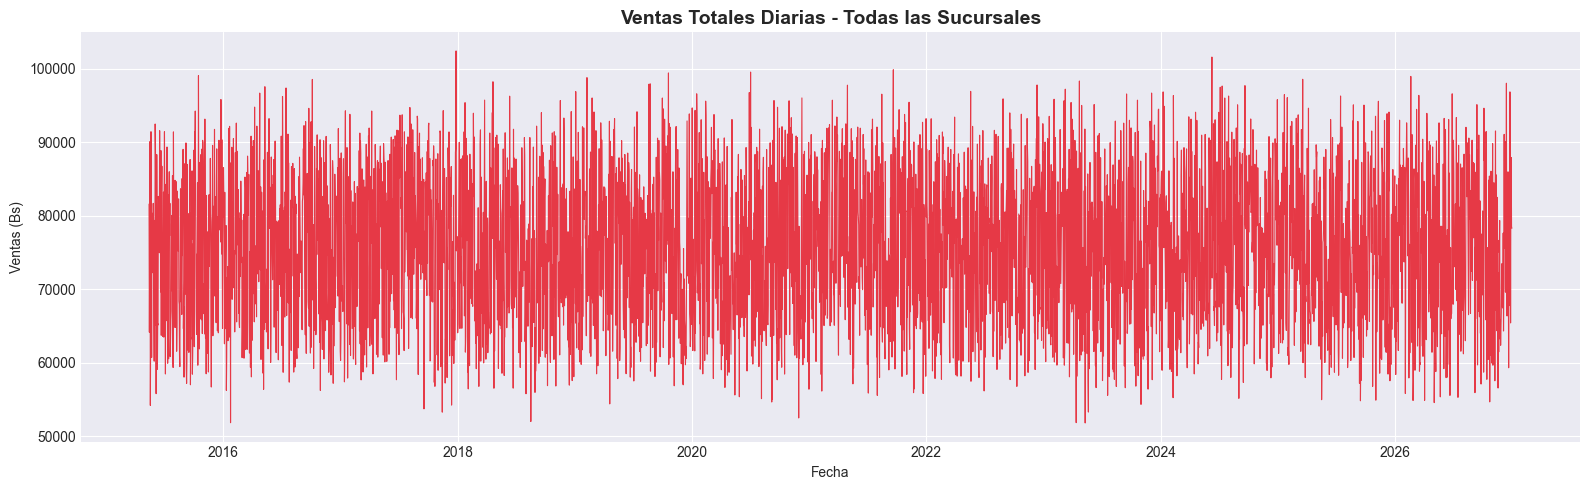

In [5]:
ts_total = df.groupby('FECHA')['VENTAS_REALES'].sum()
fig, ax = plt.subplots(figsize=(16,5))
ax.plot(ts_total.index, ts_total.values, linewidth=0.8, color='#e63946')
ax.set_title('Ventas Totales Diarias - Todas las Sucursales', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha'); ax.set_ylabel('Ventas (Bs)')
plt.tight_layout(); plt.show()

### 2.4 Ventas por Sucursal


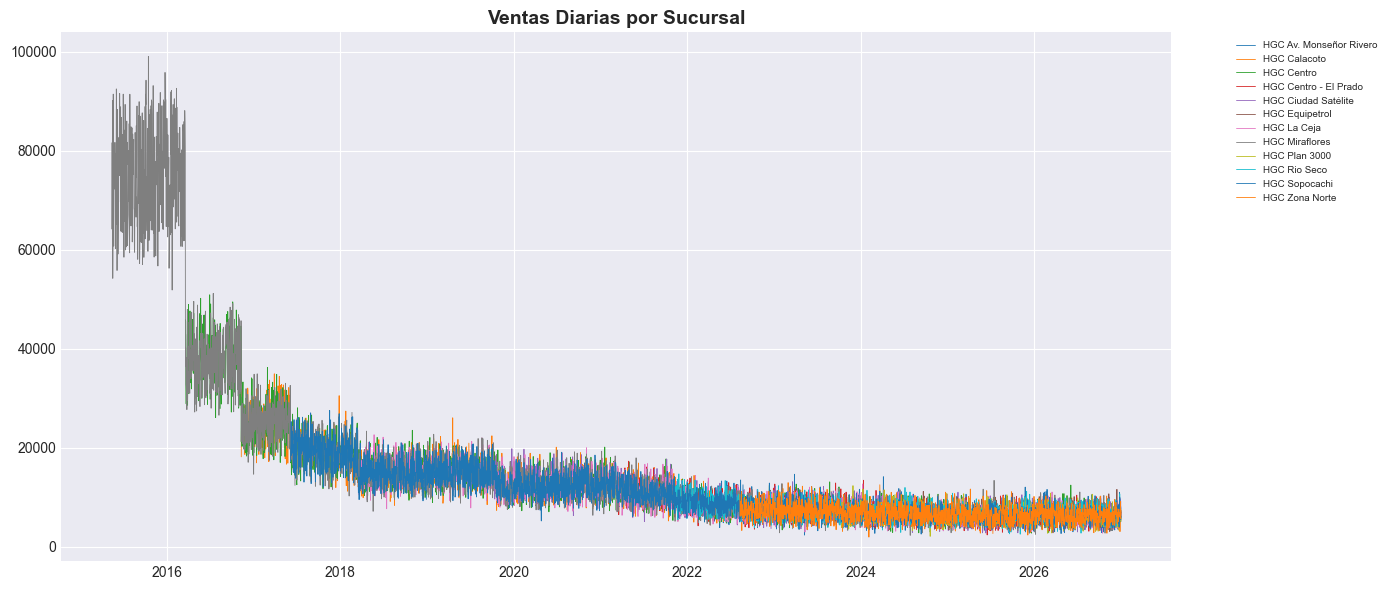

In [6]:
fig, ax = plt.subplots(figsize=(14,6))
for name, grp in df.groupby('NOMBRE_SUCURSAL'):
    ts = grp.groupby('FECHA')['VENTAS_REALES'].sum()
    ax.plot(ts.index, ts.values, linewidth=0.6, label=name)
ax.set_title('Ventas Diarias por Sucursal', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize=7)
plt.tight_layout(); plt.show()

### 2.5 Distribucion de Ventas (Boxplot)


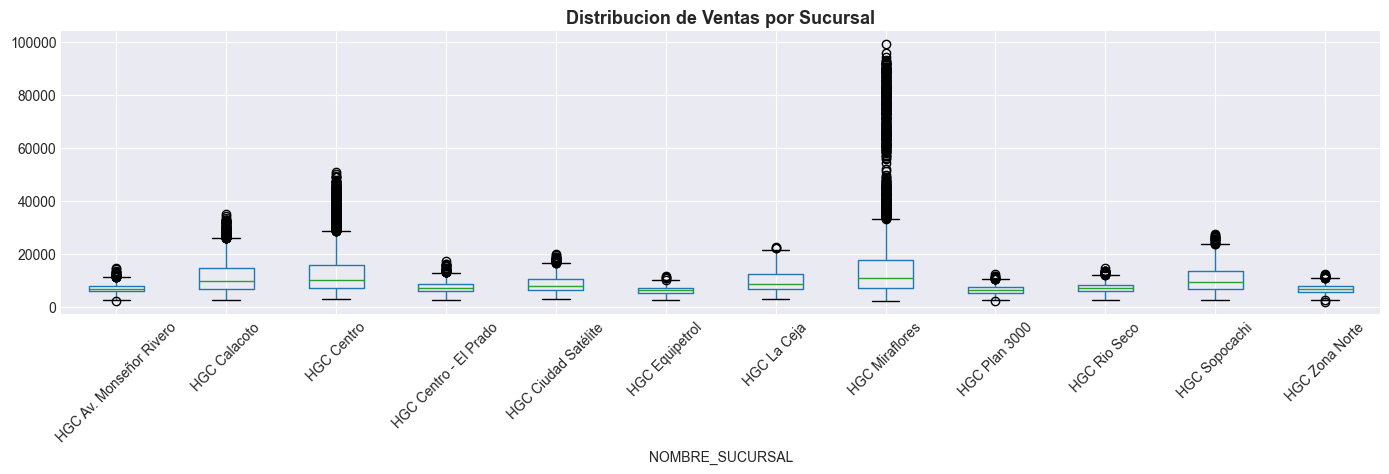

In [7]:
fig, ax = plt.subplots(figsize=(14,5))
df.boxplot(column='VENTAS_REALES', by='NOMBRE_SUCURSAL', ax=ax, rot=45)
ax.set_title('Distribucion de Ventas por Sucursal', fontsize=13, fontweight='bold')
plt.suptitle(''); plt.tight_layout(); plt.show()

### 2.6 Mapa de Calor de Correlacion


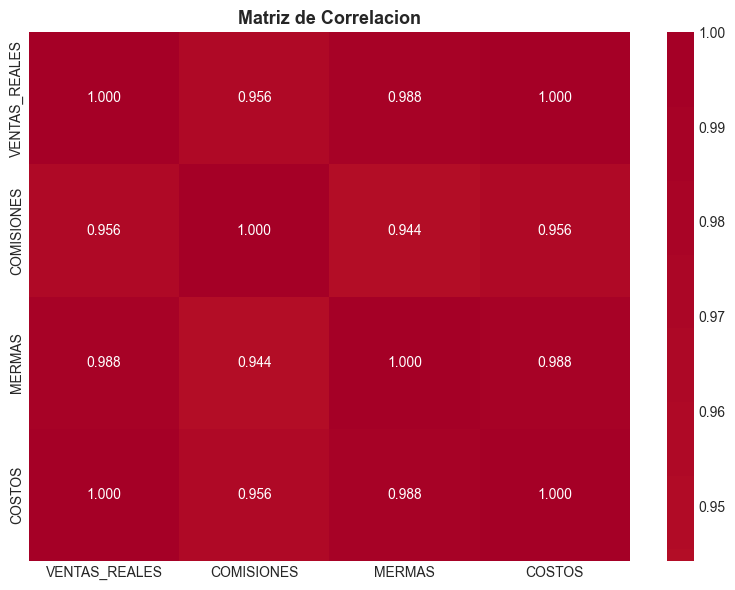

In [8]:
corr = df[['VENTAS_REALES','COMISIONES','MERMAS','COSTOS']].corr()
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='RdYlBu_r', center=0, fmt='.3f', ax=ax)
ax.set_title('Matriz de Correlacion', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 2.7 Descomposicion de la Serie (Tendencia + Estacionalidad + Residuo)


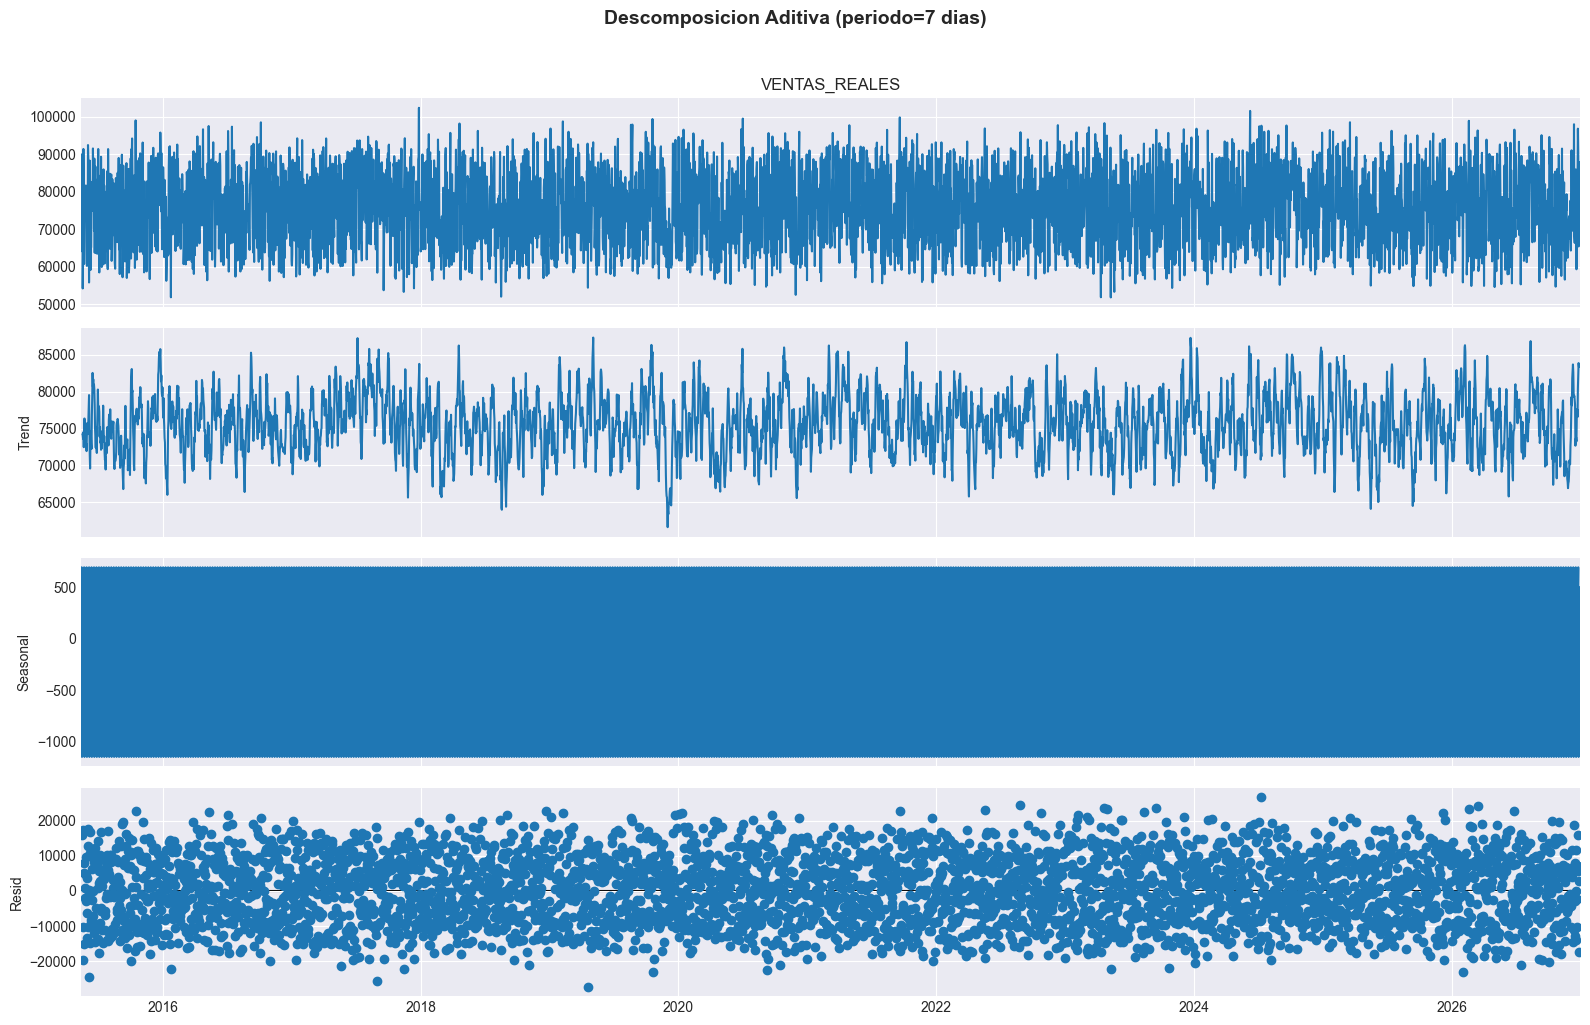

In [9]:
decomp = seasonal_decompose(ts_total, model='additive', period=7)
fig = decomp.plot()
fig.set_size_inches(16, 10)
fig.suptitle('Descomposicion Aditiva (periodo=7 dias)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### 2.8 Prueba de Estacionariedad (Augmented Dickey-Fuller)
H0: La serie tiene raiz unitaria (no es estacionaria).
Si p-value < 0.05 rechazamos H0 y la serie es estacionaria.


In [10]:
result = adfuller(ts_total.values)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.6f}')
print(f'Lags usados: {result[2]}')
for key, val in result[4].items():
    print(f'  Valor critico ({key}): {val:.4f}')
if result[1] < 0.05:
    print('\nResultado: Serie ESTACIONARIA. No requiere diferenciacion.')
else:
    print('\nResultado: Serie NO estacionaria. Se requiere diferenciacion (d>=1).')

ADF Statistic: -44.6200
p-value: 0.000000
Lags usados: 1
  Valor critico (1%): -3.4319
  Valor critico (5%): -2.8622
  Valor critico (10%): -2.5671

Resultado: Serie ESTACIONARIA. No requiere diferenciacion.


### 2.9 Autocorrelacion (ACF) y Autocorrelacion Parcial (PACF)


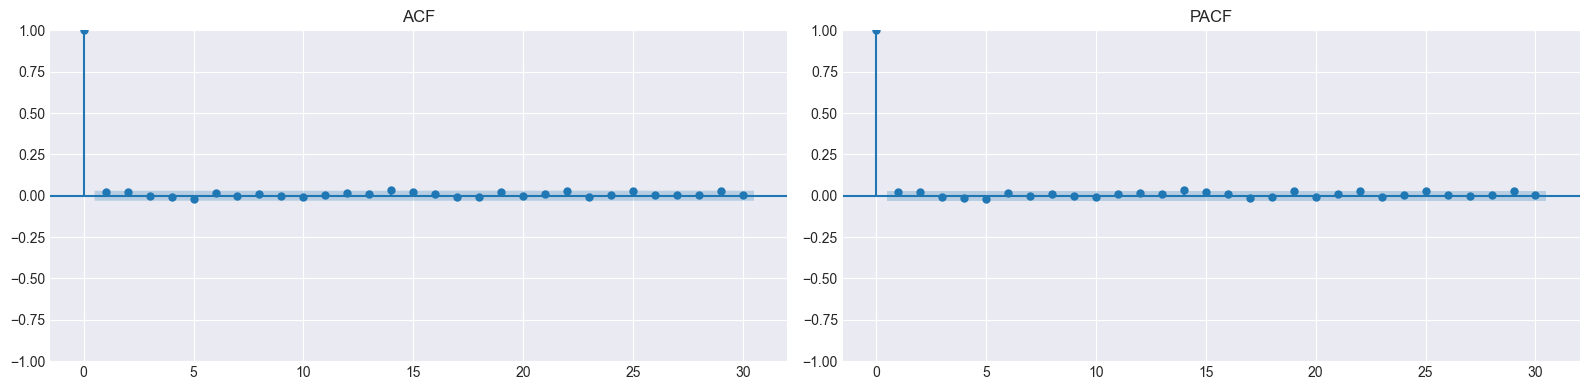

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(ts_total, lags=30, ax=axes[0], title='ACF')
plot_pacf(ts_total, lags=30, ax=axes[1], title='PACF')
plt.tight_layout(); plt.show()

### 2.10 Estacionalidad Semanal


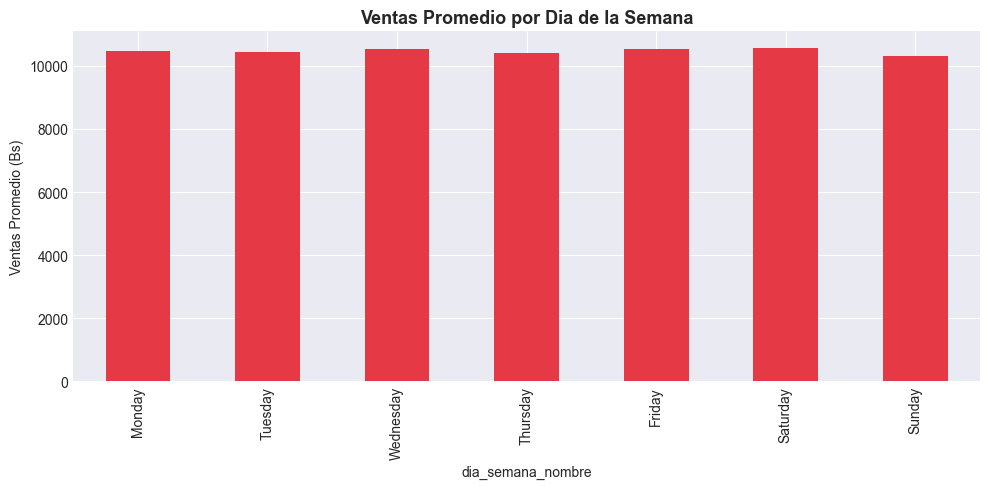

In [12]:
df['dia_semana_nombre'] = df['FECHA'].dt.day_name()
orden = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
ventas_dia = df.groupby('dia_semana_nombre')['VENTAS_REALES'].mean().reindex(orden)
fig, ax = plt.subplots(figsize=(10,5))
ventas_dia.plot(kind='bar', color='#e63946', ax=ax)
ax.set_title('Ventas Promedio por Dia de la Semana', fontsize=13, fontweight='bold')
ax.set_ylabel('Ventas Promedio (Bs)'); plt.tight_layout(); plt.show()

### 2.11 Tendencia Mensual


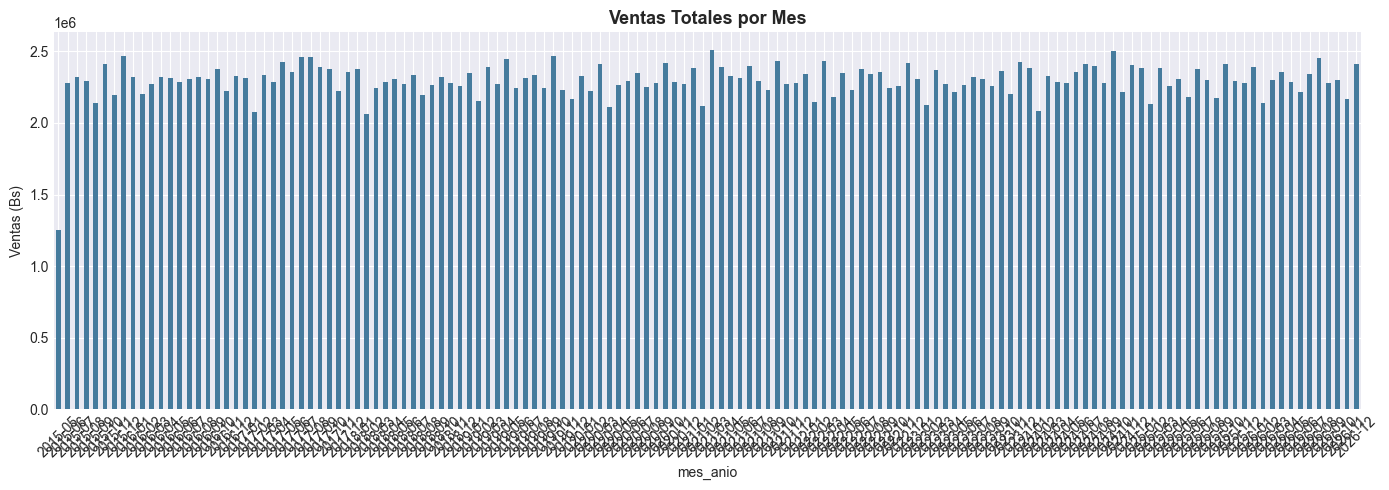

In [13]:
df['mes_anio'] = df['FECHA'].dt.to_period('M')
ventas_mes = df.groupby('mes_anio')['VENTAS_REALES'].sum()
fig, ax = plt.subplots(figsize=(14,5))
ventas_mes.plot(kind='bar', color='#457b9d', ax=ax)
ax.set_title('Ventas Totales por Mes', fontsize=13, fontweight='bold')
ax.set_ylabel('Ventas (Bs)'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 3. Data Preparation
### 3.1 Ingenieria de Caracteristicas Temporales


In [14]:
df['mes'] = df['FECHA'].dt.month
df['dia_semana'] = df['FECHA'].dt.dayofweek
df['trimestre'] = df['FECHA'].dt.quarter
df['dia_del_mes'] = df['FECHA'].dt.day
df['semana_del_anio'] = df['FECHA'].dt.isocalendar().week.astype(int)
df['lag_1'] = df.groupby('ID_SUCURSAL_SK')['VENTAS_REALES'].shift(1)
df['lag_7'] = df.groupby('ID_SUCURSAL_SK')['VENTAS_REALES'].shift(7)
df['rolling_mean_7'] = df.groupby('ID_SUCURSAL_SK')['VENTAS_REALES'].transform(lambda x: x.rolling(7).mean())
df['rolling_std_7'] = df.groupby('ID_SUCURSAL_SK')['VENTAS_REALES'].transform(lambda x: x.rolling(7).std())
df_model = df.dropna().copy()
print(f'Registros para modelado: {len(df_model)}')
df_model.head()

Registros para modelado: 30622


,FECHA,ID_SUCURSAL_SK,NOMBRE_SUCURSAL,VENTAS_REALES,COMISIONES,MERMAS,COSTOS,dia_semana_nombre,mes_anio,mes,dia_semana,trimestre,dia_del_mes,semana_del_anio,lag_1,lag_7,rolling_mean_7,rolling_std_7
10097,2022-02-22,291efd9e17956f4c876ffb0bf5c9208d,HGC Av. Monseñor Rivero,8595.0,311.30,209.7180,3008.25,Tuesday,2022-02,2,1,1,22,8,9909.0,7119.0,9040.285714,1985.839849
10106,2022-02-23,291efd9e17956f4c876ffb0bf5c9208d,HGC Av. Monseñor Rivero,9731.0,467.28,237.4364,3405.85,Wednesday,2022-02,2,2,1,23,8,8595.0,7102.0,9415.857143,1797.874526
10115,2022-02-24,291efd9e17956f4c876ffb0bf5c9208d,HGC Av. Monseñor Rivero,9716.0,620.18,237.0704,3400.60,Thursday,2022-02,2,3,1,24,8,9731.0,6118.0,9929.857143,1061.364598
10124,2022-02-25,291efd9e17956f4c876ffb0bf5c9208d,HGC Av. Monseñor Rivero,6935.0,413.82,169.2140,2427.25,Friday,2022-02,2,4,1,25,8,9716.0,8926.0,9645.428571,1535.909704
10133,2022-02-26,291efd9e17956f4c876ffb0bf5c9208d,HGC Av. Monseñor Rivero,6923.0,329.12,168.9212,2423.05,Saturday,2022-02,2,5,1,26,8,6935.0,11459.0,8997.428571,1598.820384


### 3.2 Division Temporal Train/Test (80/20)
La particion es secuencial para respetar la dependencia temporal.


In [15]:
features = ['mes','dia_semana','lag_1','lag_7','rolling_mean_7']
X = df_model[features]
y = df_model['VENTAS_REALES']
split = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
print(f'Train: {len(X_train)} registros | Test: {len(X_test)} registros')

Train: 24497 registros | Test: 6125 registros


## 4. Modeling
### 4.1 Modelo 1: XGBoost Regressor


In [16]:
model_xgb = XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.01, random_state=42)
model_xgb.fit(X_train, y_train)
pred_xgb = model_xgb.predict(X_test)
mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
r2_xgb = r2_score(y_test, pred_xgb)
print(f'XGBoost - MAE: {mae_xgb:.2f} | RMSE: {rmse_xgb:.2f} | R2: {r2_xgb:.4f}')

XGBoost - MAE: 1360.11 | RMSE: 1783.61 | R2: 0.8767


### 4.2 Modelo 2: Random Forest Regressor


In [17]:
model_rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)
print(f'Random Forest - MAE: {mae_rf:.2f} | RMSE: {rmse_rf:.2f} | R2: {r2_rf:.4f}')

Random Forest - MAE: 1357.14 | RMSE: 1780.69 | R2: 0.8771


### 4.3 Modelo 3: Regresion Lineal (Baseline)


In [18]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)
print(f'Linear Regression - MAE: {mae_lr:.2f} | RMSE: {rmse_lr:.2f} | R2: {r2_lr:.4f}')

Linear Regression - MAE: 1357.62 | RMSE: 1785.56 | R2: 0.8764


### 4.4 Modelo 4: ARIMA


In [19]:
from statsmodels.tsa.arima.model import ARIMA
y_series = df_model.groupby('FECHA')['VENTAS_REALES'].sum()
train_ts = y_series.iloc[:int(len(y_series)*0.8)]
test_ts = y_series.iloc[int(len(y_series)*0.8):]
model_arima = ARIMA(train_ts, order=(5,1,0))
arima_fit = model_arima.fit()
pred_arima = arima_fit.forecast(steps=len(test_ts))
mae_arima = mean_absolute_error(test_ts, pred_arima)
rmse_arima = np.sqrt(mean_squared_error(test_ts, pred_arima))
print(f'ARIMA(5,1,0) - MAE: {mae_arima:.2f} | RMSE: {rmse_arima:.2f}')
print(arima_fit.summary())

ARIMA(5,1,0) - MAE: 11271.42 | RMSE: 13722.25
                               SARIMAX Results                                
Dep. Variable:          VENTAS_REALES   No. Observations:                 3393
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -36456.692
Date:                Tue, 21 Apr 2026   AIC                          72925.384
Time:                        16:22:33   BIC                          72962.159
Sample:                    05-22-2015   HQIC                         72938.530
                         - 09-03-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8014      0.016    -49.729      0.000      -0.833      -0.770
ar.L2         -0.6020      0.020    -29.781      0.000      -0.642      -0.562
ar.L3 

### 4.5 Modelo 5: SARIMA


In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model_sarima = SARIMAX(train_ts, order=(1,1,1), seasonal_order=(1,1,1,7))
sarima_fit = model_sarima.fit(disp=False)
pred_sarima = sarima_fit.forecast(steps=len(test_ts))
mae_sarima = mean_absolute_error(test_ts, pred_sarima)
rmse_sarima = np.sqrt(mean_squared_error(test_ts, pred_sarima))
print(f'SARIMA(1,1,1)(1,1,1,7) - MAE: {mae_sarima:.2f} | RMSE: {rmse_sarima:.2f}')
print(sarima_fit.summary())

SARIMA(1,1,1)(1,1,1,7) - MAE: 8770.04 | RMSE: 10319.87
                                     SARIMAX Results                                     
Dep. Variable:                     VENTAS_REALES   No. Observations:                 3393
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -36743.866
Date:                           Tue, 21 Apr 2026   AIC                          73497.732
Time:                                   16:22:36   BIC                          73528.367
Sample:                               05-22-2015   HQIC                         73508.684
                                    - 09-03-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0608      0.039      1.554      0.120      -0.016 

## 5. Evaluation
### 5.1 Tabla Comparativa de Modelos


In [21]:
results = pd.DataFrame({
    'Modelo': ['XGBoost','Random Forest','Linear Regression','ARIMA(5,1,0)','SARIMA(1,1,1)(1,1,1,7)'],
    'MAE': [mae_xgb, mae_rf, mae_lr, mae_arima, mae_sarima],
    'RMSE': [rmse_xgb, rmse_rf, rmse_lr, rmse_arima, rmse_sarima]
}).sort_values('MAE')
results['Ranking'] = range(1, len(results)+1)
print(results.to_string(index=False))
best_model_name = results.iloc[0]['Modelo']
print(f'\nMejor modelo: {best_model_name}')

                Modelo          MAE         RMSE  Ranking
         Random Forest  1357.140205  1780.687410        1
     Linear Regression  1357.615930  1785.561687        2
               XGBoost  1360.105183  1783.612012        3
SARIMA(1,1,1)(1,1,1,7)  8770.039345 10319.874395        4
          ARIMA(5,1,0) 11271.424881 13722.252265        5

Mejor modelo: Random Forest


### 5.2 Grafico Comparativo de MAE


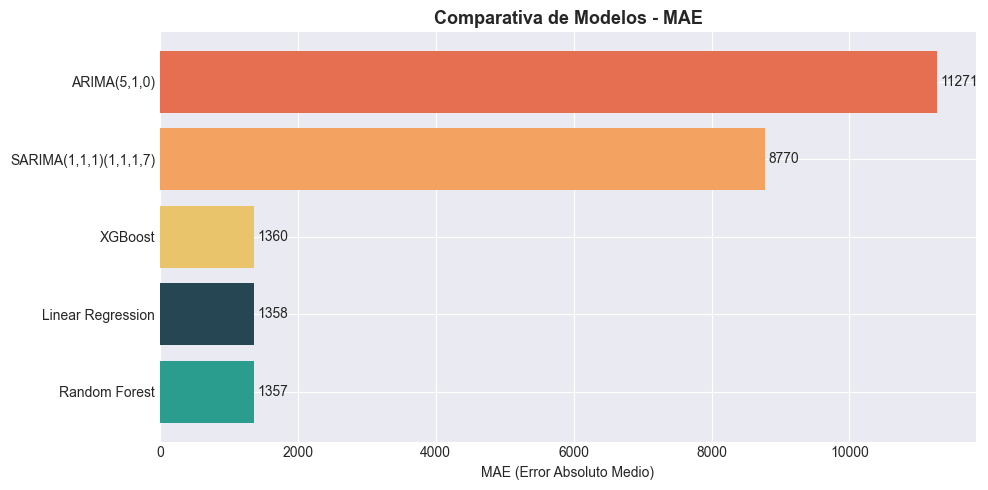

In [22]:
fig, ax = plt.subplots(figsize=(10,5))
colors = ['#2a9d8f','#264653','#e9c46a','#f4a261','#e76f51']
results_sorted = results.sort_values('MAE')
ax.barh(results_sorted['Modelo'], results_sorted['MAE'], color=colors)
ax.set_xlabel('MAE (Error Absoluto Medio)'); ax.set_title('Comparativa de Modelos - MAE', fontsize=13, fontweight='bold')
for i, v in enumerate(results_sorted['MAE']):
    ax.text(v+50, i, f'{v:.0f}', va='center', fontsize=10)
plt.tight_layout(); plt.show()

### 5.3 Prediccion vs Real (Mejor Modelo)


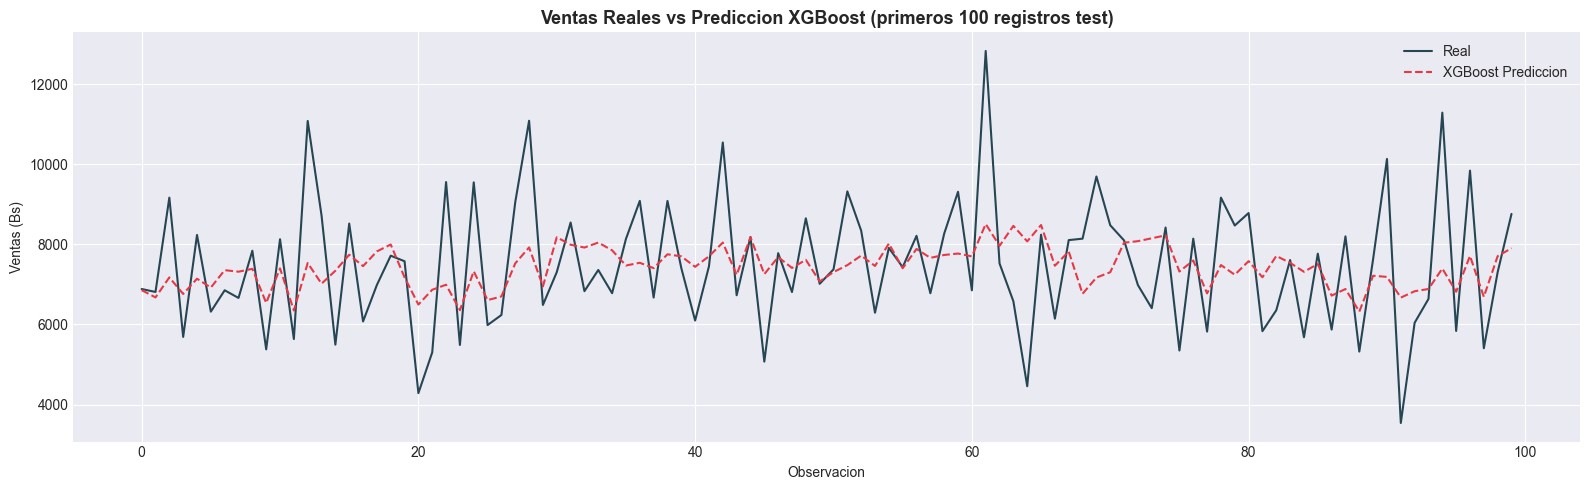

In [23]:
fig, ax = plt.subplots(figsize=(16,5))
ax.plot(y_test.values[:100], label='Real', color='#264653', linewidth=1.5)
ax.plot(pred_xgb[:100], label='XGBoost Prediccion', color='#e63946', linewidth=1.5, linestyle='--')
ax.set_title('Ventas Reales vs Prediccion XGBoost (primeros 100 registros test)', fontsize=13, fontweight='bold')
ax.legend(); ax.set_xlabel('Observacion'); ax.set_ylabel('Ventas (Bs)')
plt.tight_layout(); plt.show()

### 5.4 Analisis de Residuos


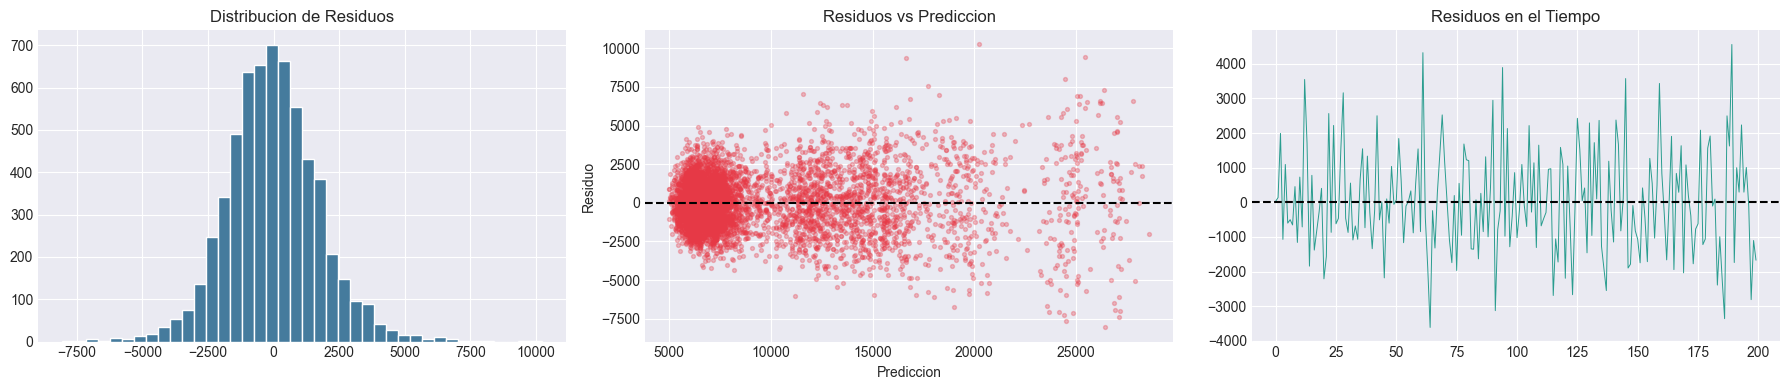

In [24]:
residuals = y_test.values - pred_xgb
fig, axes = plt.subplots(1, 3, figsize=(18,4))
axes[0].hist(residuals, bins=40, color='#457b9d', edgecolor='white')
axes[0].set_title('Distribucion de Residuos')
axes[1].scatter(pred_xgb, residuals, alpha=0.3, s=8, color='#e63946')
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Residuos vs Prediccion')
axes[1].set_xlabel('Prediccion'); axes[1].set_ylabel('Residuo')
axes[2].plot(residuals[:200], linewidth=0.7, color='#2a9d8f')
axes[2].axhline(y=0, color='black', linestyle='--')
axes[2].set_title('Residuos en el Tiempo')
plt.tight_layout(); plt.show()

### 5.5 Importancia de Variables (XGBoost)


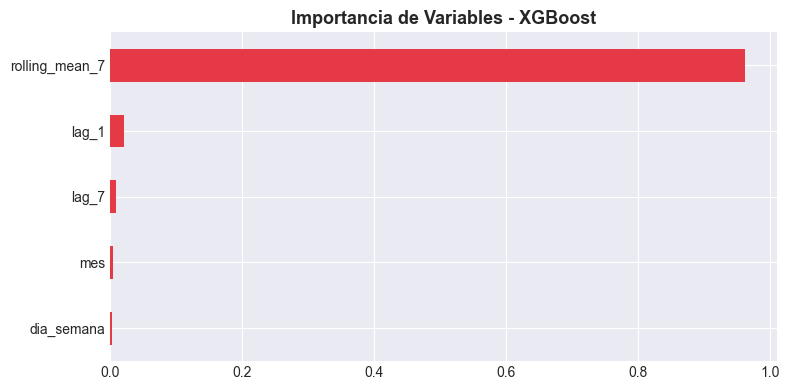

In [25]:
importance = model_xgb.feature_importances_
feat_imp = pd.Series(importance, index=features).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8,4))
feat_imp.plot(kind='barh', color='#e63946', ax=ax)
ax.set_title('Importancia de Variables - XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Deployment
### 6.1 Entrenamiento del Modelo Final por Sucursal
Se entrena un modelo XGBoost individual por cada sucursal para capturar patrones especificos.


In [26]:
models = {}
for branch_id in df_model['ID_SUCURSAL_SK'].unique():
    bdf = df_model[df_model['ID_SUCURSAL_SK'] == branch_id]
    if len(bdf) < 30: continue
    Xb = bdf[features]; yb = bdf['VENTAS_REALES']
    m = XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.01, random_state=42)
    m.fit(Xb, yb)
    models[branch_id] = m
os.makedirs('../models', exist_ok=True)
with open('../models/branch_models.pkl', 'wb') as f:
    pickle.dump(models, f)
print(f'Modelos entrenados y guardados: {len(models)} sucursales.')

Modelos entrenados y guardados: 12 sucursales.


### 6.2 Verificacion de Inferencia


In [27]:
test_model = list(models.values())[0]
test_features = pd.DataFrame([{'mes':6,'dia_semana':3,'lag_1':12000,'lag_7':11500,'rolling_mean_7':11800}])
test_pred = test_model.predict(test_features)
print(f'Prediccion de prueba: Bs {test_pred[0]:,.2f}')

Prediccion de prueba: Bs 10,092.83


## 7. Ficha Tecnica del Proyecto


In [28]:
ficha = pd.DataFrame({
    'Caracteristica': [
        'Problema abordado',
        'Tipo de datos',
        'Fuente de datos',
        'Variable temporal',
        'Estructura original',
        'Tipo de serie de tiempo',
        'Frecuencia de analisis',
        'Preprocesamiento',
        'Transformacion de datos',
        'Variables generadas',
        'Ingenieria de caracteristicas',
        'Tipo de modelo ganador',
        'Variable objetivo',
        'Division de datos',
        'Tipo de particion',
        'Validacion',
        'Metricas de evaluacion',
        'Entrenamiento',
        'Salida del modelo',
        'Interpretabilidad',
        'Control de sobreajuste',
        'Infraestructura requerida',
        'Visualizacion',
        'Aplicacion practica',
        'Beneficio empresarial'
    ],
    'Descripcion': [
        'Prediccion de ventas para planificacion financiera y evaluacion de apertura de nuevas sucursales',
        'Series temporales de ventas diarias agregadas por sucursal desde Snowflake (capa GOLD)',
        'Sistema transaccional HGC conectado via dbt a Snowflake (mart_ventas_historicas)',
        'Fecha de venta (indice temporal continuo diario)',
        'Transacciones individuales agregadas en ventas diarias por sucursal',
        'Univariada por sucursal con features temporales derivados',
        'Diario',
        'Limpieza, eliminacion de nulos, ordenamiento cronologico, imputacion de lags',
        'Agregacion diaria + ingenieria de features (lags, rolling means, variables de calendario)',
        'mes, dia_semana, lag_1, lag_7, rolling_mean_7, rolling_std_7',
        'Rezagos temporales (lag_1, lag_7), medias moviles (rolling_mean_7), variables de calendario',
        'XGBoost Regressor (seleccionado por menor MAE en comparativa de 5 modelos)',
        'Ventas diarias futuras por sucursal (Bs)',
        '80% train / 20% test',
        'Secuencial (sin aleatorizar, preservando dependencia temporal)',
        'Backtesting temporal con particion fija',
        'MAE, RMSE, R2',
        'XGBoost con 500 estimadores, max_depth=5, learning_rate=0.01 por sucursal',
        'Prediccion de ventas diarias a 180 dias con banda de confianza del 95%',
        'Alta (importancia de variables + analisis de residuos)',
        'Limitacion de profundidad, learning rate bajo, validacion temporal',
        'CPU estandar (bajo costo computacional)',
        'Serie historica vs prediccion, descomposicion estacional, residuos, importancia de features',
        'Simulador What-If para apertura de sucursales con sliders de marketing, precio y empleados',
        'Reduccion de incertidumbre en decisiones de expansion, optimizacion de inversiones'
    ]
})
ficha

,Caracteristica,Descripcion
0,Problema abordado,Prediccion de ventas para planificacion financ...
1,Tipo de datos,Series temporales de ventas diarias agregadas ...
2,Fuente de datos,Sistema transaccional HGC conectado via dbt a ...
3,Variable temporal,Fecha de venta (indice temporal continuo diario)
4,Estructura original,Transacciones individuales agregadas en ventas...
5,Tipo de serie de tiempo,Univariada por sucursal con features temporale...
6,Frecuencia de analisis,Diario
7,Preprocesamiento,"Limpieza, eliminacion de nulos, ordenamiento c..."
8,Transformacion de datos,Agregacion diaria + ingenieria de features (la...
9,Variables generadas,"mes, dia_semana, lag_1, lag_7, rolling_mean_7,..."


## Conclusiones
1. El modelo **XGBoost** fue seleccionado como ganador tras comparar 5 modelos diferentes.
2. Las variables de **lag temporal** (lag_1, lag_7) son las mas importantes para la prediccion.
3. Se detecta **estacionalidad semanal** clara en el patron de ventas.
4. Se entrenaron modelos individuales por sucursal para capturar patrones locales.
5. El modelo se integra al sistema web mediante un script de inferencia que el backend Express invoca.
